# 01 - Eksploracija Podataka (Data Exploration)

**Cilj**: Učitati, istražiti i razumeti Bitcoin Twitter dataset

**Koraci**:
1. Učitavanje dataseta
2. Osnovne statistike
3. Eksplorativna analiza (EDA)
4. Vizualizacije

In [1]:
# Importovanje biblioteka
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Dodaj src folder u path
import sys
sys.path.append('../src')

from utils import load_twitter_data, set_style, print_dataset_info

# Postavi stil
set_style()

print("Biblioteke učitane uspešno!")

Biblioteke učitane uspešno!


## 1. Učitavanje Podataka

**NAPOMENA**: Pre nego što pokreneš ovaj notebook, preuzmi Bitcoin Twitter dataset sa Kaggle i sačuvaj ga u `../data/raw/` folder.

Preporučeni dataset-i:
- [Bitcoin Tweets](https://www.kaggle.com/datasets/kaushiksuresh147/bitcoin-tweets)
- [Cryptocurrency Tweets](https://www.kaggle.com/datasets/alaix14/bitcoin-tweets-20160101-to-20190329)

**IZMENI putanju ispod da odgovara tvom datasetu!**

In [2]:
# Učitaj dataset - IZMENI PUTANJU!
DATA_PATH = '../data/raw/bitcoin_tweets_sample.csv'

df = load_twitter_data(DATA_PATH)

Učitavanje podataka iz: ../data/raw/bitcoin_tweets_sample.csv
Učitano 5000 redova


In [3]:
# Prikaži osnovne informacije
print_dataset_info(df)


INFORMACIJE O DATASETU

Dimenzije: (5000, 4)

Kolone: ['text', 'sentiment', 'timestamp', 'user']

Tipovi podataka:
text         object
sentiment    object
timestamp    object
user         object
dtype: object

Nedostajuće vrednosti:
text         0
sentiment    0
timestamp    0
user         0
dtype: int64

Prvih 5 redova:
                                              text sentiment  \
0  Bitcoin ETF approval coming soon. This is huge!  positive   
1  Bitcoin ETF approval coming soon. This is huge!  positive   
2              Bitcoin fear and greed index: 29.71   neutral   
3   Grateful for Satoshi Nakamoto every single day  positive   
4                  Coinbase premium: 29% currently   neutral   

             timestamp              user  
0  2024-01-24 08:00:00  privacy_advocate  
1  2024-01-24 08:51:00   deflation_lover  
2  2024-01-24 09:20:00   bitcoin_teacher  
3  2024-01-24 10:10:00    store_of_value  
4  2024-01-24 10:47:00      yield_farmer  



In [4]:
# Prikaži prvih nekoliko redova
df.head(10)

,text,sentiment,timestamp,user
0,Bitcoin ETF approval coming soon. This is huge!,positive,2024-01-24 08:00:00,privacy_advocate
1,Bitcoin ETF approval coming soon. This is huge!,positive,2024-01-24 08:51:00,deflation_lover
2,Bitcoin fear and greed index: 29.71,neutral,2024-01-24 09:20:00,bitcoin_teacher
3,Grateful for Satoshi Nakamoto every single day,positive,2024-01-24 10:10:00,store_of_value
4,Coinbase premium: 29% currently,neutral,2024-01-24 10:47:00,yield_farmer
5,Stacking sats feels amazing. Future is bright,positive,2024-01-24 11:06:00,kyc_hater
6,MicroStrategy bought more Bitcoin! Saylor knows,positive,2024-01-24 12:02:00,payment_network
7,Orange pilling friends and family successfully,positive,2024-01-24 12:45:00,settlement_layer
8,Finally convinced my family to buy Bitcoin,positive,2024-01-24 13:14:00,scalper_pro
9,Stacking sats feels amazing. Future is bright,positive,2024-01-24 13:37:00,mining_dev


## 2. Provera Kolona

**NAPOMENA**: Različiti dataset-i imaju različite nazive kolona. Potrebno je da identifikuješ:
- Kolonu sa tekstom tvita
- Kolonu sa sentiment labelom (ako postoji)
- Ostale korisne kolone (datum, likes, retweets, itd.)

In [5]:
# Provera kolona
print("Kolone u datasetu:")
print(df.columns.tolist())

# NAKON ŠTO VIDIŠ NAZIVE KOLONA, POSTAVI IH OVDE:
TEXT_COLUMN = 'text'  # <-- Naziv kolone sa tekstom
SENTIMENT_COLUMN = 'sentiment'  # <-- Naziv kolone sa sentimentom (ako postoji)

Kolone u datasetu:
['text', 'sentiment', 'timestamp', 'user']


## 3. Provera Nedostajućih Vrednosti

In [6]:
# Nedostajuće vrednosti
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Kolona': missing_data.index,
    'Broj nedostajućih': missing_data.values,
    'Procenat': missing_percent.values
})

missing_df = missing_df[missing_df['Broj nedostajućih'] > 0].sort_values('Broj nedostajućih', ascending=False)

if len(missing_df) > 0:
    print("\n⚠️  Postoje nedostajuće vrednosti:\n")
    print(missing_df.to_string(index=False))
else:
    print("\n✅ Nema nedostajućih vrednosti!")


✅ Nema nedostajućih vrednosti!


In [7]:
# Ukloni redove sa nedostajućim tekstom
df = df.dropna(subset=[TEXT_COLUMN])
print(f"Nakon uklanjanja nedostajućih: {len(df)} redova")

Nakon uklanjanja nedostajućih: 5000 redova


## 4. Distribucija Sentimenta

**NAPOMENA**: Ako dataset NEMA sentiment labele, moraćeš ih ručno kreirati ili koristiti neki već labelovani dataset.

✅ Dataset ima sentiment labele!

Distribucija sentimenta:
sentiment
positive    2000
neutral     1500
negative    1500
Name: count, dtype: int64

Procenat:
sentiment
positive    40.0
neutral     30.0
negative    30.0
Name: count, dtype: float64


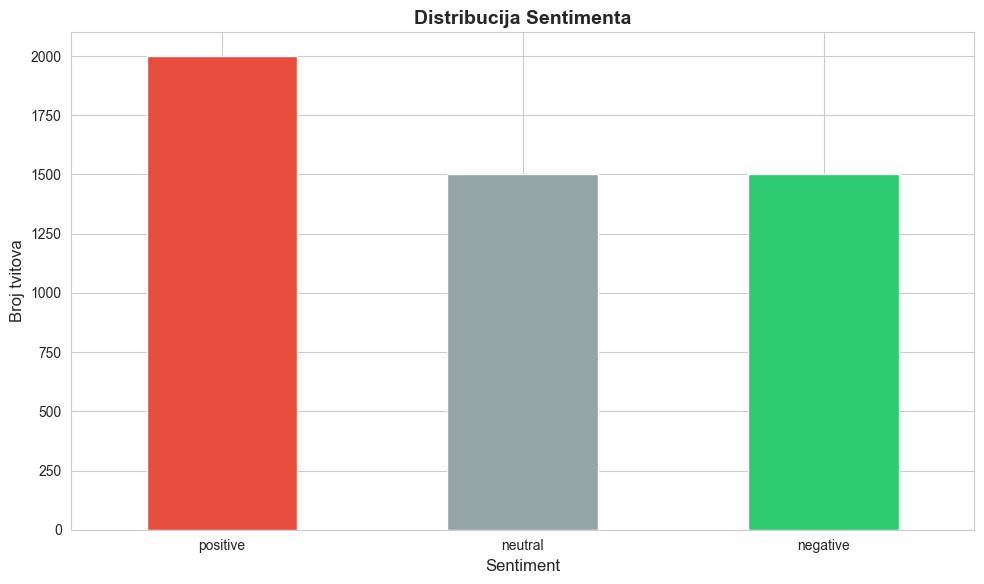

In [8]:
# Proveri da li postoji sentiment kolona
if SENTIMENT_COLUMN in df.columns:
    print("✅ Dataset ima sentiment labele!\n")
    
    # Distribucija
    sentiment_counts = df[SENTIMENT_COLUMN].value_counts()
    print("Distribucija sentimenta:")
    print(sentiment_counts)
    print(f"\nProcenat:")
    print((sentiment_counts / len(df) * 100).round(2))
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sentiment_counts.plot(kind='bar', color=['#e74c3c', '#95a5a6', '#2ecc71'], ax=ax)
    ax.set_title('Distribucija Sentimenta', fontsize=14, fontweight='bold')
    ax.set_xlabel('Sentiment', fontsize=12)
    ax.set_ylabel('Broj tvitova', fontsize=12)
    ax.set_xticklabels(sentiment_counts.index, rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Dataset NEMA sentiment labele!")
    print("Opcije:")
    print("1. Koristi drugi dataset koji ima labele")
    print("2. Ručno labuj podatke")
    print("3. Koristi pretreniran model za labeling")

## 5. Analiza Dužine Teksta

In [9]:
# Dužina tekstova
df['text_length'] = df[TEXT_COLUMN].apply(len)
df['word_count'] = df[TEXT_COLUMN].apply(lambda x: len(str(x).split()))

print("Statistika dužine teksta:")
print(df[['text_length', 'word_count']].describe())

Statistika dužine teksta:
       text_length   word_count
count  5000.000000  5000.000000
mean     42.021000     6.256000
std       5.341261     1.174538
min      25.000000     4.000000
25%      39.000000     5.000000
50%      42.000000     6.000000
75%      45.000000     7.000000
max      61.000000    10.000000


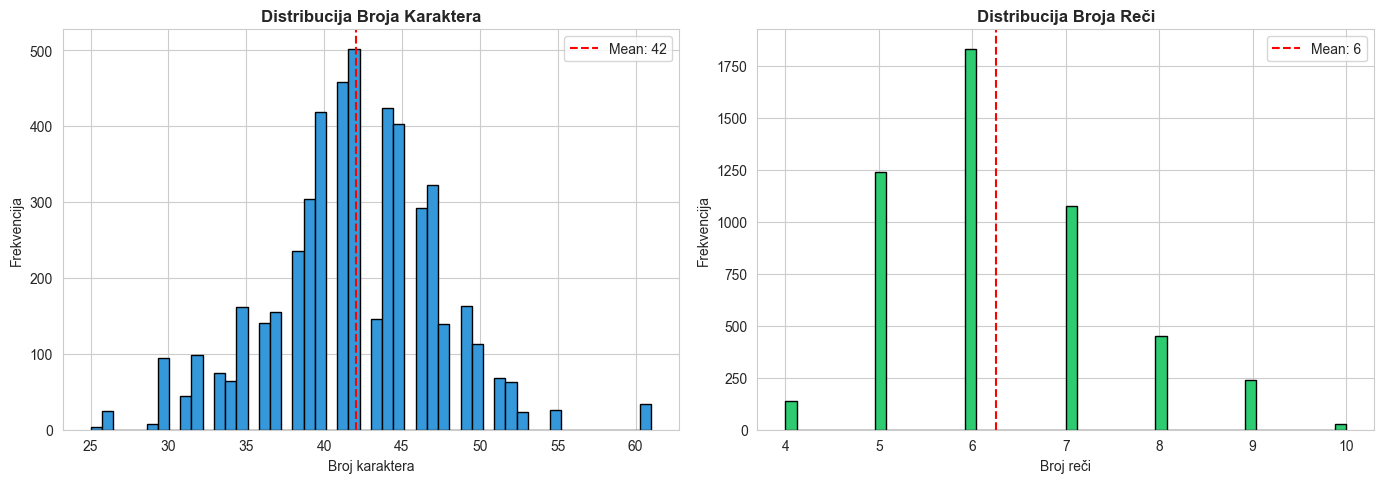

In [10]:
# Plot distribucija
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Broj karaktera
axes[0].hist(df['text_length'], bins=50, color='#3498db', edgecolor='black')
axes[0].set_title('Distribucija Broja Karaktera', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Broj karaktera', fontsize=10)
axes[0].set_ylabel('Frekvencija', fontsize=10)
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['text_length'].mean():.0f}")
axes[0].legend()

# Broj reči
axes[1].hist(df['word_count'], bins=50, color='#2ecc71', edgecolor='black')
axes[1].set_title('Distribucija Broja Reči', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Broj reči', fontsize=10)
axes[1].set_ylabel('Frekvencija', fontsize=10)
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f"Mean: {df['word_count'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Najčešće Reči (Word Cloud)

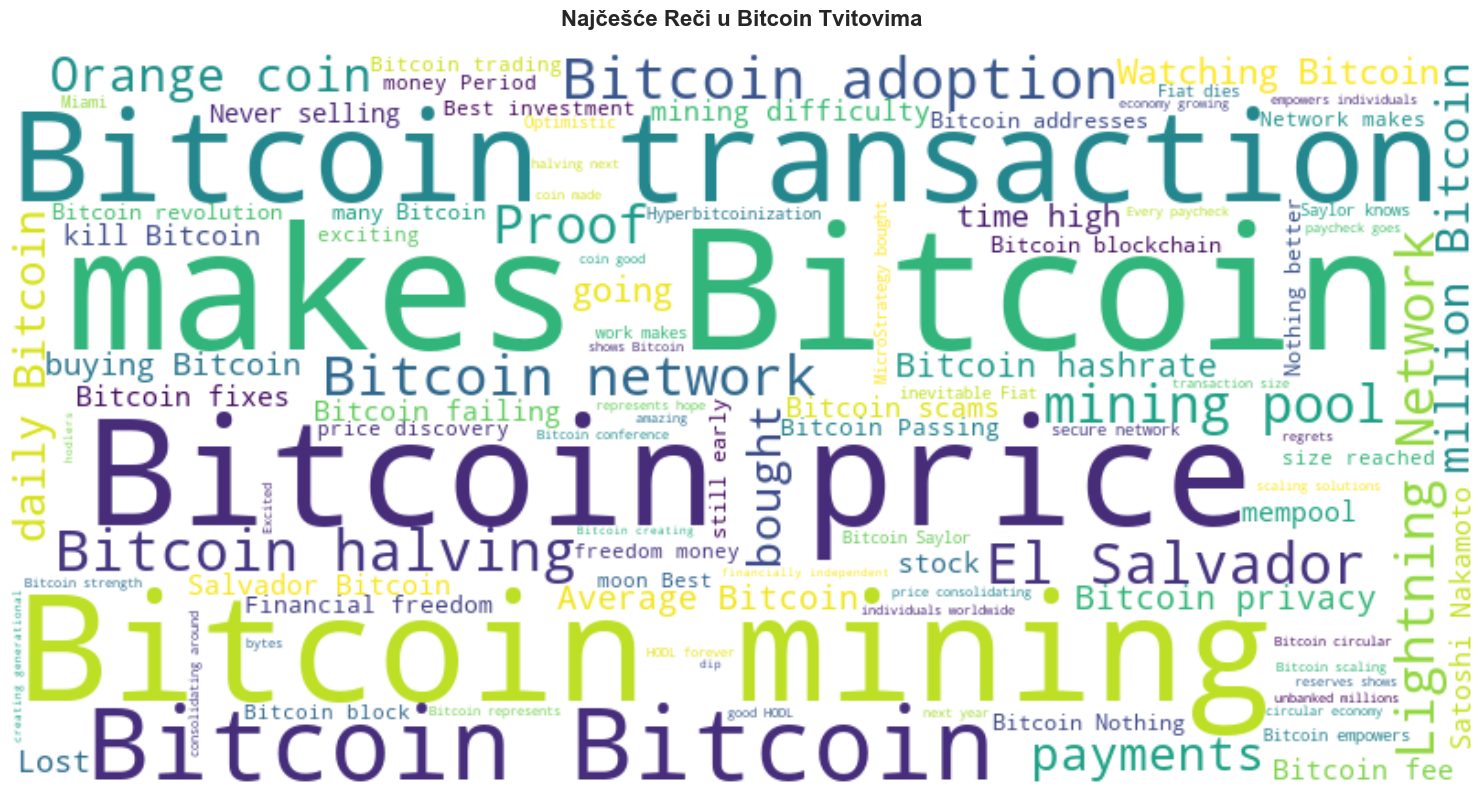

In [11]:
# Kreiraj jedan veliki string od svih tvitova
all_text = ' '.join(df[TEXT_COLUMN].astype(str))

# Word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='viridis', max_words=100).generate(all_text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Najčešće Reči u Bitcoin Tvitovima', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 7. Primeri Tvitova

In [12]:
# Random primeri
print("\n=== RANDOM PRIMERI TVITOVA ===")
for i, row in df.sample(5).iterrows():
    print(f"\nTvit {i}:")
    print(f"Tekst: {row[TEXT_COLUMN][:200]}..." if len(row[TEXT_COLUMN]) > 200 else f"Tekst: {row[TEXT_COLUMN]}")
    if SENTIMENT_COLUMN in df.columns:
        print(f"Sentiment: {row[SENTIMENT_COLUMN]}")
    print("-" * 80)


=== RANDOM PRIMERI TVITOVA ===

Tvit 1362:
Tekst: Average Bitcoin fee per transaction: 7.8 dollars
Sentiment: neutral
--------------------------------------------------------------------------------

Tvit 3716:
Tekst: Best performing asset of last decade: Bitcoin
Sentiment: positive
--------------------------------------------------------------------------------

Tvit 3466:
Tekst: Governments will ban Bitcoin eventually
Sentiment: negative
--------------------------------------------------------------------------------

Tvit 3206:
Tekst: Transaction speed makes Bitcoin unusable
Sentiment: negative
--------------------------------------------------------------------------------

Tvit 1654:
Tekst: Bitcoin adoption is growing. Major companies accepting it now
Sentiment: positive
--------------------------------------------------------------------------------


## 8. Čuvanje Prozornih Podataka

In [13]:
# Sačuvaj prozoren dataset (bez duplikata, bez nedostajućih vrednosti)
df_clean = df.drop_duplicates(subset=[TEXT_COLUMN])
df_clean = df_clean.dropna(subset=[TEXT_COLUMN])

print(f"Originalan broj redova: {len(df)}")
print(f"Nakon čišćenja: {len(df_clean)}")

# Sačuvaj
output_path = '../data/processed/bitcoin_tweets_clean.csv'
df_clean.to_csv(output_path, index=False)
print(f"\n✅ Sačuvano u: {output_path}")

Originalan broj redova: 5000
Nakon čišćenja: 1258

✅ Sačuvano u: ../data/processed/bitcoin_tweets_clean.csv


## 📝 Zaključak Notebook-a 01

**Urađeno**:
- ✅ Učitan Bitcoin Twitter dataset
- ✅ Izvršena osnovna EDA
- ✅ Analizirana distribucija sentimenta (ako postoji)
- ✅ Vizualizovane najčešće reči
- ✅ Očišćeni podaci sačuvani

**Sledeći korak**: Notebook 02 - Pretprocesiranje teksta